In [95]:
name = "Elena Vezenkoska"
id = 2600210

In [96]:
# Select the data file based on your student ID
n = id % 5 # Take the modulo 5 of your student ID
num_list = [3, 4, 6, 8, 9] # List of numbers to select from
filename = f'./data/bidmc_{num_list[n]:02d}_Signals.csv'
print(f'Filename: {filename}')

Filename: ./data/bidmc_03_Signals.csv


In [97]:
# Run if needed
#%pip install numpy pandas matplotlib scipy

In [98]:
# Read necessary libraries and functions
import numpy as np                  # for numerical operations
import matplotlib.pyplot as plt     # for plotting
import pandas as pd                 # for reading data
from scipy.signal import find_peaks # for peak detection
import os                           # for file operations

In [99]:
# Print the list of files in the ./data directory
os.listdir('./data')

['bidmc_02_Fix.txt',
 'bidmc_02_Signals.csv',
 'bidmc_03_Fix.txt',
 'bidmc_03_Signals.csv',
 'bidmc_04_Fix.txt',
 'bidmc_04_Signals.csv',
 'bidmc_06_Fix.txt',
 'bidmc_06_Signals.csv',
 'bidmc_08_Fix.txt',
 'bidmc_08_Signals.csv',
 'bidmc_09_Fix.txt',
 'bidmc_09_Signals.csv']

In [100]:
# Read the data
data = pd.read_csv(filename)

# Get PPG signal and create time vector
ppg = data[' PLETH']
s_time = 0.008 # Sample time in seconds
S_frequency = 1/s_time # Sample rate (Hz), samples per second
t = np.arange(len(ppg))*s_time

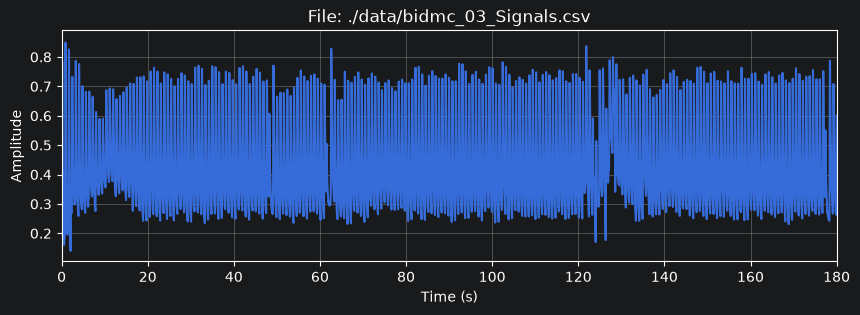

In [101]:
# Plot 180 seconds of the full signal
plt.figure(figsize = (10, 3))
plt.plot(t, ppg)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'File: {filename}')
plt.xlim(0, 180)
plt.grid()
plt.show()

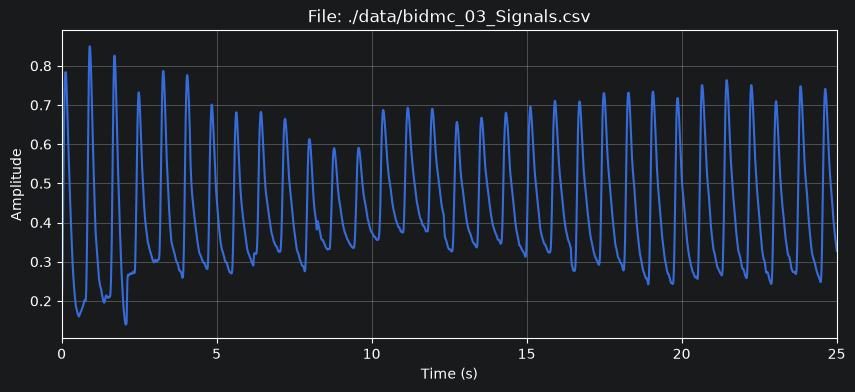

In [102]:
plt.figure(figsize = (10, 4))
plt.plot(t, ppg)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'File: {filename}')
plt.xlim(0, 25)
plt.grid()
plt.show()

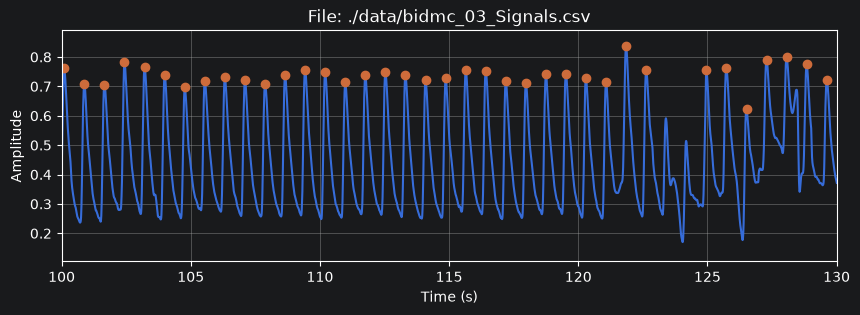

In [103]:
peaks, properties = find_peaks(ppg, height=0.6, distance=50)

plt.figure(figsize = (10, 3))
plt.plot(t, ppg)
plt.plot(t[peaks], ppg[peaks], 'o')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'File: {filename}')
plt.xlim(100, 130)
plt.grid()
plt.show()

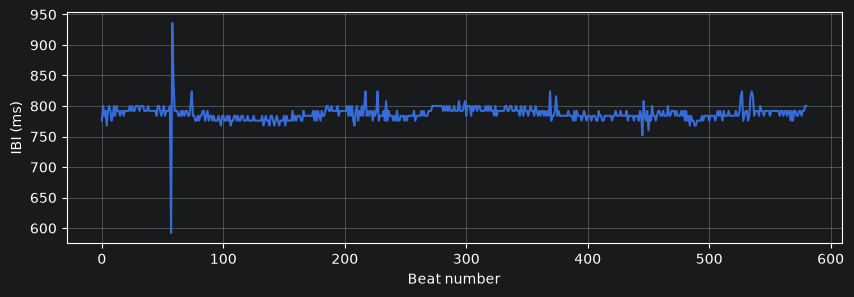

In [104]:
ppi = np.diff(peaks)*s_time*1000
i = (ppi > 500) & (ppi < 1000)
ppi = ppi[i]
plt.figure(figsize = (10, 3))
plt.plot(ppi)
plt.xlabel('Beat number')
plt.ylabel('IBI (ms)')
plt.grid()
plt.show()

In [105]:
mean_ppi = np.mean(ppi)
print(f'Mean IBI is {mean_ppi:.2f} ms')

hr = 60000/mean_ppi
print(f'Your heart rate is {hr:.2f} bpm')

sdnn = np.std(ppi)
print(f'The SDNN is {sdnn:.2f} ms')

rmssd = np.sqrt(np.mean(np.diff(ppi) ** 2))
print(f'The RMSSD is {rmssd:.2f} ms')

Mean IBI is 787.39 ms
Your heart rate is 76.20 bpm
The SDNN is 13.91 ms
The RMSSD is 20.32 ms


In [106]:
# INTERPRETATION
# The average heartrate is high for the patients age and gender, because the average resting heartrate should be between 60 and 70 BPM for females.

# The PPI is lower than normal beacuse a PPI of 800 or less is considered low, meaning less time between heartbeats

# The SDNN and RMSSD are both low and the variation in general is lower than standard values

#the stress level is high and the recovery status is low